# Supervisor agents

Aqui, usaremos agentes como tools. Deixamos um agente supervisionando o restante dos outros agentes, que serão nesse caso nutridos de funções

## Criando agentes que serão supervisionados

### Agente de busca

In [2]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

resp = search.invoke("Lakers próximo jogo")

In [10]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv, find_dotenv
import os
load_dotenv(find_dotenv())

llm_search = init_chat_model(model="groq:openai/gpt-oss-120b", api_key=os.getenv("GROQ_API_KEY"), temperature=0.2)
search_agent = create_agent(
    model=llm_search,
    tools=[search],
    name="search agent",
    system_prompt="Você é um ótimo buscador de itens na internet"
)

### Criando agente que realiza cálculos matemáticos

In [11]:
def add(a: float, b: float) -> float:
    """Adiciona dois números"""
    return a + b

def multiply(a: float, b: float) -> float:
    """Multiplica dois números"""
    return a * b

In [12]:
llm_math = init_chat_model(model="groq:openai/gpt-oss-20b", api_key=os.getenv("GROQ_API_KEY"), temperature=0.2)

math_agent = create_agent(
    model=llm_math,
    tools=[multiply, add],
    name="Agente matemático",
    system_prompt="Você é o melhor em fazer operações de multiplicação e adição com dois números"
)

### Criando o agente supervisor

In [14]:
from langgraph_supervisor import create_supervisor

supervisor_llm = init_chat_model(model="groq:openai/gpt-oss-20b", api_key=os.getenv("GROQ_API_KEY"), temperature=0.2)

workflow = create_supervisor(
    [search_agent, math_agent],
    model=supervisor_llm,
    prompt=(
        "Você é um agente supervisor e é capaz de delegar tarefas de buscas na internet e"
        " tarefas de realizar cálculos matemáticos"
    )
)

In [15]:
app = workflow.compile()

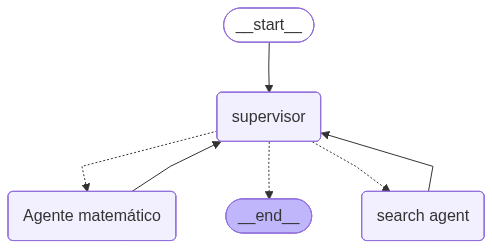

In [18]:
app

In [19]:
result = app.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Quanto foi o jogo do Lakers vs Miami Heat?"
        }
    ]
})

In [ ]:
result["messages"]

[HumanMessage(content='Quanto foi o jogo do Lakers vs Miami Heat?', additional_kwargs={}, response_metadata={}, id='d001909d-927c-45a7-9056-162e829a0a09'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "Quanto foi o jogo do Lakers vs Miami Heat?" Likely wants the score of a Lakers vs Miami Heat game. Need to find recent game. Probably the last game. We need to search. Use search agent.', 'tool_calls': [{'id': 'fc_bdec13bd-c731-4655-915b-183b2834d3a7', 'function': {'arguments': '{"query":"Lakers vs Miami Heat score","top_k":5}', 'name': 'transfer_to_search_agent'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 185, 'total_tokens': 268, 'completion_time': 0.082608857, 'prompt_time': 0.009011966, 'queue_time': 0.147422087, 'total_time': 0.091620823, 'completion_tokens_details': {'reasoning_tokens': 48}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e2cb7a84ec', 'service_tier': 'on_demand', 

In [23]:
result["messages"][-1].content

'O último jogo entre **Los\u202fAngeles Lakers** e **Miami Heat** terminou com a vitória dos Lakers por **130 a 120**.'